In [10]:
from tensor_contraction import TensorNetwork, TensorNetworkOptimizer, State
import numpy as np

In [11]:
def generate_lambda(probability, n):
    '''
    Generate matrix lambd[i,j]
    lambd[i,j] == 1 => RZZ will act on i-th and j-th qubit
    '''
    lambd = np.zeros((n, n))
    for i in range(n):
        for j in range(i):
            if np.random.rand() < probability:
                lambd[i, j] = 1
    return lambd


def generate_lambda_nearest(n):
    '''
    Generate coupling matrix with nearest neighbor interaction
    '''
    lambd = np.zeros((n, n))
    for i in range(n):
        lambd[(i+1) % n, i] = 1
    return lambd

In [12]:
n_layers = 1
prob = 1.0
n_qubits = 3

gammas = np.array([np.pi]) # np.random.uniform(0, 2*np.pi, size=n_layers)
betas = np.array([0]) #np.random.uniform(0, 2*np.pi, size=n_layers)
lambd = generate_lambda(prob, n_qubits)

In [13]:
'''
Generate tensor net without measurement layer, so raw output state is generated after contraction
'''
net = TensorNetwork.qaoa_like_from_params(lambd, gammas, betas, generate_meas_layer=False)

In [14]:
lambd

array([[0., 0., 0.],
       [1., 0., 0.],
       [1., 1., 0.]])

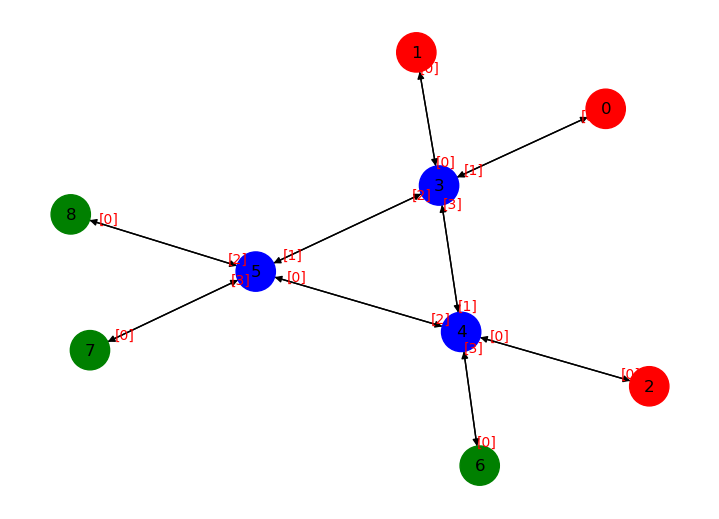

In [15]:
'''
Red - input state
Green - rx
Blue - rzz
'''
net.draw_network()

In [16]:
'''
Optimize network, and show ouptut state after greedy sequence
'''
opt = TensorNetworkOptimizer(net)
seq, cost = opt.optimize_network(k=2)
print(seq)
for (i,j) in seq:
    print('\n---\n')
    net.merge_nodes(i,j, actually_contract=True)
    for i in net.active_nodes:
        print(net.nodes[i].tensor)

[(1, 0), (2, 0), (3, 0), (4, 0), (6, 0), (5, 0), (7, 0), (8, 0)]

---

[[0.5 0.5]
 [0.5 0.5]]
[0.70710678 0.70710678]
[[[[6.123234e-17-1.j 0.000000e+00+0.j]
   [0.000000e+00+0.j 0.000000e+00+0.j]]

  [[0.000000e+00+0.j 6.123234e-17+1.j]
   [0.000000e+00+0.j 0.000000e+00+0.j]]]


 [[[0.000000e+00+0.j 0.000000e+00+0.j]
   [6.123234e-17+1.j 0.000000e+00+0.j]]

  [[0.000000e+00+0.j 0.000000e+00+0.j]
   [0.000000e+00+0.j 6.123234e-17-1.j]]]]
[[[[6.123234e-17-1.j 0.000000e+00+0.j]
   [0.000000e+00+0.j 0.000000e+00+0.j]]

  [[0.000000e+00+0.j 6.123234e-17+1.j]
   [0.000000e+00+0.j 0.000000e+00+0.j]]]


 [[[0.000000e+00+0.j 0.000000e+00+0.j]
   [6.123234e-17+1.j 0.000000e+00+0.j]]

  [[0.000000e+00+0.j 0.000000e+00+0.j]
   [0.000000e+00+0.j 6.123234e-17-1.j]]]]
[[[[6.123234e-17-1.j 0.000000e+00+0.j]
   [0.000000e+00+0.j 0.000000e+00+0.j]]

  [[0.000000e+00+0.j 6.123234e-17+1.j]
   [0.000000e+00+0.j 0.000000e+00+0.j]]]


 [[[0.000000e+00+0.j 0.000000e+00+0.j]
   [6.123234e-17+1.j 0.000000e+00+0

In [17]:
'''
run qaoa gate by gate
'''
s = State(n_qubits)
s.run_qaoa(lambd, gammas, betas)
s.state

array([[[-6.49467042e-17+0.35355339j,  2.16489014e-17+0.35355339j],
        [ 2.16489014e-17+0.35355339j,  2.16489014e-17+0.35355339j]],

       [[ 2.16489014e-17+0.35355339j,  2.16489014e-17+0.35355339j],
        [ 2.16489014e-17+0.35355339j, -6.49467042e-17+0.35355339j]]])

In [18]:
'''
Verify result is the same
'''
np.allclose(s.state, net.nodes[0].tensor)

True